In [13]:
from util import bin_the_light_curve
import pandas as pd
import numpy as np
import os
from astropy.io import ascii
# std_pho_table = pd.read_csv('./bright_than_12_std_pho.csv')



In [17]:
table0 = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/w1_std_pho_match_table0.csv')
table1 = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/w1_std_pho_match_table1.csv')
table7 = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/w1_std_pho_match_table7.csv')
table8 = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/w1_std_pho_match_table8.csv')
table = pd.concat([table0,table1,table7,table8])
len(table)

653555

In [19]:
subtable = table.sample(5000)
subtable.columns

Index(['ra_1', 'dec_1', 'objID', 'gmag', 'e_gmag', 'rmag', 'e_rmag', 'imag',
       'e_imag', 'zmag', 'e_zmag', 'ymag', 'e_ymag', 'col1', 'Unnamed: 0',
       'id_in_matched', 'ra_2', 'dec_2', 'median', 'mean_error', 'Mean',
       'StetsonK', 'Eta_e', 'Std', 'Skew', 'SmallKurtosis', 'Con',
       'Meanvariance', 'Separation'],
      dtype='object')

(array([  10.,   56.,  139.,  248.,  363.,  526.,  734.,  982., 1085.,
         857.]),
 array([11.22047491, 11.84271605, 12.46495719, 13.08719833, 13.70943947,
        14.33168061, 14.95392175, 15.57616289, 16.19840403, 16.82064517,
        17.44288631]),
 <BarContainer object of 10 artists>)

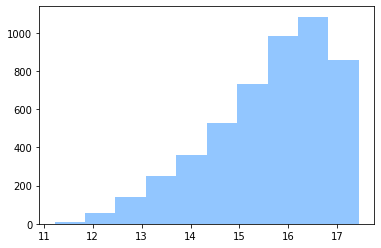

In [20]:
plt.hist(subtable['Mean'])

In [4]:
# subtable.to_csv('./sample5000_std_pho.csv') 
subtable = pd.read_csv('./sample5000_std_pho.csv') 


In [4]:
# table = table[table['Mean']<12]
# len(table)


2617

In [9]:
std_pho_table = subtable
len(std_pho_table)

5000

In [10]:
std_pho_table.columns

Index(['Unnamed: 0.1', 'ra_1', 'dec_1', 'objID', 'gmag', 'e_gmag', 'rmag',
       'e_rmag', 'imag', 'e_imag', 'zmag', 'e_zmag', 'ymag', 'e_ymag', 'col1',
       'Unnamed: 0', 'id_in_matched', 'ra_2', 'dec_2', 'median', 'mean_error',
       'Mean', 'StetsonK', 'Eta_e', 'Std', 'Skew', 'SmallKurtosis', 'Con',
       'Meanvariance', 'Separation'],
      dtype='object')

In [14]:
from util import get_data_arrays
import os
band = 'w1'
# path = './test_data/neowise_std_pho/data/'
path = './ipac/std_pho_sample5000/'
result_list = []
missed_index = []
i = 0
count = 0
length = len(std_pho_table)
print(length)
delta_w2 = []
for ra,dec in zip(std_pho_table['ra_1'],std_pho_table['dec_1']):

    std_untimely = std_pho_table.iloc[i]['Std']
    mean_error_untimely = std_pho_table.iloc[i]['mean_error']
    Mean = std_pho_table.iloc[i]['Mean']
    
    ra_str = str(ra)[0:10]
    dec_str = str(dec)[0:10]
    if os.path.isfile(path+'wise'+ra_str+'_'+dec_str+ '_neowise.ipac'):
        neowise = ascii.read(path + 'wise'+'%s_%s_neowise.ipac'%(ra_str,dec_str), format='ipac')
        neowise = neowise[
        (neowise['qual_frame'] > 0.) *
        (neowise['qi_fact'] > 0.9) *
        (neowise['saa_sep'] > 0) *
        (neowise['moon_masked'] == '00')
        ]
        t, m, e = get_data_arrays(neowise, 'mjd', band + 'mpro', band + 'sigmpro')
        if len(t)>20:
            t_index = t.argsort()
            t, m, e = map(lambda e: e[t_index], [t, m, e])
            delta_w2.append(max(m)-min(m))
            t, m, e = bin_the_light_curve(t,m,e)
            t, m, e = np.array(t),np.array(m),np.array(e)
            result_line=[ra,dec,Mean,std_untimely,mean_error_untimely,np.std(m),np.mean(e)]
            result_list.append(result_line)
            count += 1
            print(count/length)
        else:
            missed_index.append(i)
    else:
        missed_index.append(i)
    
    i+=1
            

5000
0.0002
0.0004
0.0006
0.0008


/home/kangzihan/project_unTimely_light_curve/util.py:139: UserWarning: Warning: converting a masked element to nan.
  err_median = np.median(np.array(tmp_bin_err))


0.001
0.0012
0.0014
0.0016
0.0018
0.002
0.0022
0.0024
0.0026
0.0028
0.003
0.0032
0.0034


/home/kangzihan/project_unTimely_light_curve/util.py:148: UserWarning: Warning: converting a masked element to nan.
  err_median = np.median(np.array(tmp_bin_err))


0.0036
0.0038
0.004
0.0042
0.0044
0.0046
0.0048
0.005
0.0052
0.0054
0.0056
0.0058
0.006
0.0062


/home/kangzihan/project_unTimely_light_curve/util.py:138: UserWarning: Warning: converting a masked element to nan.
  result_mag.append(np.median(np.array(tmp_bin_mag)))


0.0064
0.0066
0.0068
0.007
0.0072
0.0074
0.0076
0.0078
0.008
0.0082
0.0084
0.0086
0.0088
0.009
0.0092
0.0094
0.0096
0.0098
0.01
0.0102
0.0104
0.0106
0.0108
0.011
0.0112
0.0114
0.0116
0.0118
0.012
0.0122
0.0124
0.0126
0.0128
0.013
0.0132
0.0134
0.0136
0.0138
0.014
0.0142
0.0144
0.0146
0.0148
0.015
0.0152
0.0154
0.0156
0.0158
0.016
0.0162
0.0164
0.0166
0.0168
0.017
0.0172
0.0174
0.0176
0.0178
0.018
0.0182
0.0184
0.0186
0.0188
0.019
0.0192
0.0194
0.0196
0.0198
0.02
0.0202
0.0204
0.0206
0.0208
0.021
0.0212


/home/kangzihan/project_unTimely_light_curve/util.py:147: UserWarning: Warning: converting a masked element to nan.
  result_mag.append(np.median(np.array(tmp_bin_mag)))


0.0214
0.0216
0.0218
0.022
0.0222
0.0224
0.0226
0.0228
0.023
0.0232
0.0234
0.0236
0.0238
0.024
0.0242
0.0244
0.0246
0.0248
0.025
0.0252
0.0254
0.0256
0.0258
0.026
0.0262
0.0264
0.0266
0.0268
0.027
0.0272
0.0274
0.0276
0.0278
0.028
0.0282
0.0284
0.0286
0.0288
0.029
0.0292
0.0294
0.0296
0.0298
0.03
0.0302
0.0304
0.0306
0.0308
0.031
0.0312
0.0314
0.0316
0.0318
0.032
0.0322
0.0324
0.0326
0.0328
0.033
0.0332
0.0334
0.0336
0.0338
0.034
0.0342
0.0344
0.0346
0.0348
0.035
0.0352
0.0354
0.0356
0.0358
0.036
0.0362
0.0364
0.0366
0.0368
0.037
0.0372
0.0374
0.0376
0.0378
0.038
0.0382
0.0384
0.0386
0.0388
0.039
0.0392
0.0394
0.0396
0.0398
0.04
0.0402
0.0404
0.0406
0.0408
0.041
0.0412
0.0414
0.0416
0.0418
0.042
0.0422
0.0424
0.0426
0.0428
0.043
0.0432
0.0434
0.0436
0.0438
0.044
0.0442
0.0444
0.0446
0.0448
0.045
0.0452
0.0454
0.0456
0.0458
0.046
0.0462
0.0464
0.0466
0.0468
0.047
0.0472
0.0474
0.0476
0.0478
0.048
0.0482
0.0484
0.0486
0.0488
0.049
0.0492
0.0494
0.0496
0.0498
0.05
0.0502
0.0504
0.0506
0.0

In [15]:
print(len(result_list))
print(missed_index)

4500
[11, 16, 17, 18, 20, 37, 42, 53, 54, 56, 57, 60, 66, 78, 81, 99, 104, 111, 114, 125, 145, 162, 173, 176, 196, 198, 203, 209, 230, 237, 247, 249, 251, 266, 281, 296, 317, 319, 330, 334, 336, 337, 342, 356, 369, 373, 394, 398, 415, 418, 419, 425, 427, 438, 450, 472, 476, 484, 493, 499, 502, 505, 506, 510, 520, 522, 532, 548, 561, 565, 585, 594, 615, 647, 651, 655, 661, 676, 677, 678, 685, 694, 712, 713, 734, 742, 745, 747, 790, 794, 798, 818, 823, 839, 842, 844, 848, 851, 856, 863, 887, 891, 894, 923, 937, 941, 951, 979, 990, 994, 996, 1001, 1010, 1016, 1036, 1038, 1048, 1049, 1070, 1077, 1084, 1085, 1090, 1097, 1113, 1114, 1140, 1146, 1157, 1160, 1164, 1188, 1212, 1220, 1240, 1241, 1254, 1270, 1271, 1276, 1285, 1286, 1302, 1331, 1334, 1341, 1348, 1349, 1355, 1360, 1387, 1390, 1404, 1406, 1411, 1414, 1433, 1434, 1437, 1441, 1452, 1459, 1462, 1484, 1491, 1498, 1501, 1503, 1507, 1513, 1516, 1545, 1552, 1561, 1568, 1571, 1578, 1588, 1608, 1618, 1620, 1647, 1652, 1674, 1680, 1683, 1690,

In [59]:
len(std_pho_table)

5000

In [16]:
filtered_std_pho_table = std_pho_table.reset_index().drop(missed_index)
len(filtered_std_pho_table)

4500

(array([  10.,   50.,  138.,  229.,  356.,  494.,  694.,  936., 1061.,
         532.]),
 array([11.22047491, 11.83319332, 12.44591173, 13.05863014, 13.67134854,
        14.28406695, 14.89678536, 15.50950376, 16.12222217, 16.73494058,
        17.34765899]),
 <BarContainer object of 10 artists>)

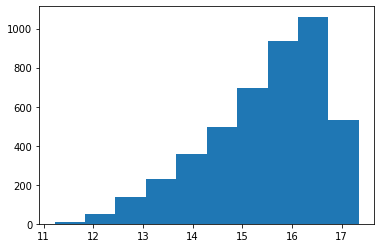

In [7]:
import matplotlib.pyplot as plt
plt.hist(filtered_std_pho_table['Mean'])

In [8]:
import pickle
with open('./tempfiles/std_pho_neowise_data.pkl', 'wb') as f:
    pickle.dump(result_list, f)
# with open('./tempfiles/std_pho_neowise_data.pkl', 'rb') as f:
#     result_list = pickle.load(f)

In [42]:
extra_para_table = pd.read_csv('./tempfiles/final_type.csv')
extra_para_table.columns

Index(['Index', 'avg_W1', 'stdev_W1', 'avg_eW1', 'avg_W2', 'stdev_W2',
       'avg_eW2', 'N_w1', 'N_w2', 'slope_w1', 'slope_w2', 'sd_sdfid_w1_flux',
       'sd_sdfid_w2_flux', 'sd_sdfid_w1_mag', 'sd_sdfid_w2_mag', 'Delta_w1',
       'Delta_w2', 'Delta_w1_flux', 'Delta_w2_flux', 'Sw1', 'DeltaSw1', 'Sw2',
       'DeltaSw2', 'SDw1', 'SDfidw1', 'SDw2', 'SDfidw2', 'chi2_mean_w1',
       'chi2_wmean_w1', 'chi2_slope_w1', 'chi2_mean_w2', 'chi2_wmean_w2',
       'chi2_slope_w2', 'linear_fap_w1', 'linear_fap_w2', 'center_mag_w1',
       'center_mag_w2', 'max_W1', 'min_W1', 'median_W1', 'max_W2', 'min_W2',
       'median_W2', 'period', 'power', 'baluev_fap', 'single_fap',
       'mod_baluev_fap', 'amp', 'sinamp', 'ls_meanjy', 'sd_sdfid_periodrmv',
       'sd_periodrmv', 'chi2_period_w2', 'linear_fap_periodrmv',
       'Deltaw2_periodrmv', 'var_type', 'combined_type', 'sd_linrmv',
       'mu_linrmv', 'sd_mu_linrmv', 'Deltaw2_linrmv'],
      dtype='object')

In [43]:
delta_w2_ysos = np.array(extra_para_table['Delta_w2'])
mean_error_ysos = np.array(extra_para_table['avg_eW2'])  

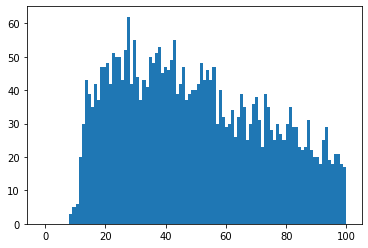

In [48]:
import matplotlib.pyplot as plt
plt.hist(np.divide(delta_w2_ysos,
                   mean_error_ysos),bins=100,range=(-1,100))
plt.show()

In [12]:
len(delta_w2)

2249

In [9]:
print(len(result_list))

2249


In [21]:
print(result_list[0])

[359.6500854, -1.2361362, 0.0121691299334, nan, 0.008883128519793511, 0.009690447323098745]


In [14]:
import matplotlib.pyplot as plt
print("可用样式列表:", plt.style.available)
import matplotlib
import seaborn as sns
print("Matplotlib版本:", matplotlib.__version__)
print("Seaborn版本:", sns.__version__)

可用样式列表: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'tableau-colorblind10']
Matplotlib版本: 3.5.3
Seaborn版本: 0.13.2


In [18]:
result_table = pd.DataFrame(np.array(result_list),columns=('ra','dec','Mean','std_untimely','mean_error_untimely',
                                           'std_neowise_bin','mean_error_neowise_bin'))

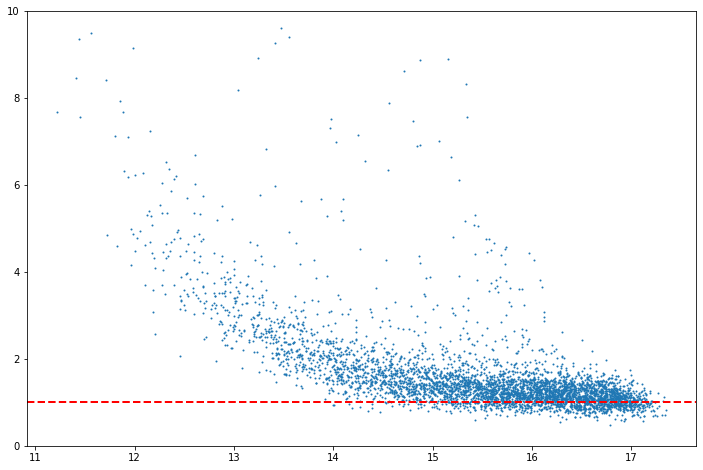

In [10]:
plt.figure(figsize=(12, 8))
plt.scatter( np.array(result_table['Mean']),
         np.divide(np.array(result_table['std_untimely']),np.array(result_table['mean_error_untimely']) ), 
         s=1)
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='1')
plt.ylim(0,10)
plt.show()

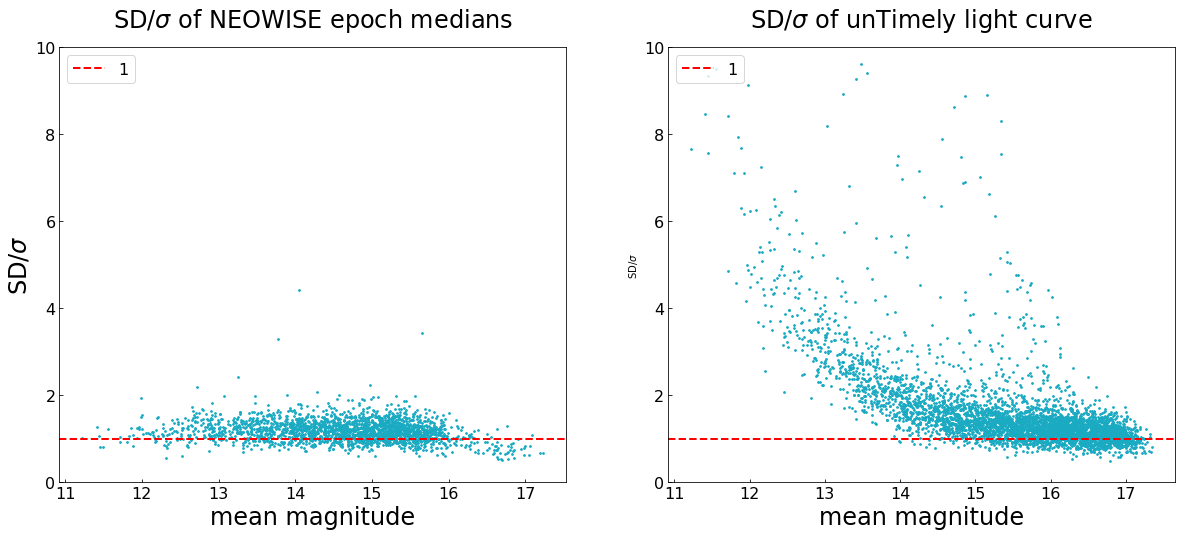

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

    
plt.style.use('seaborn-pastel')

plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.scatter( np.array(result_table['Mean']),
         np.divide(np.array(result_table['std_neowise_bin']),np.array(result_table['mean_error_neowise_bin']) ), 
         s=3, c='#1AAAC2')
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='1')
plt.ylim(0,10)
plt.legend(fontsize=16, loc='upper left')
plt.title("SD/$\sigma$ of NEOWISE epoch medians", fontsize=24,pad=20)
plt.xlabel('mean magnitude', fontsize=24)
plt.ylabel('SD/$\sigma$', fontsize=24)
plt.tick_params(labelsize=16,axis='both',direction='in')

plt.subplot(1, 2, 2)
plt.scatter( np.array(result_table['Mean']),
         np.divide(np.array(result_table['std_untimely']),np.array(result_table['mean_error_untimely']) ), 
         s=3, c='#1AAAC2')
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='1')
plt.ylim(0,10)
plt.legend(fontsize=16, loc='upper left')
plt.title("SD/$\sigma$ of unTimely light curve", fontsize=24 ,pad=20)
plt.xlabel('mean magnitude', fontsize=24)
plt.ylabel('SD/$\sigma$')
plt.tick_params(labelsize=16,axis='both',direction='in')


plt.savefig('./figs/SD_sigma_vs_mean_mag.svg',format='svg')
plt.show()

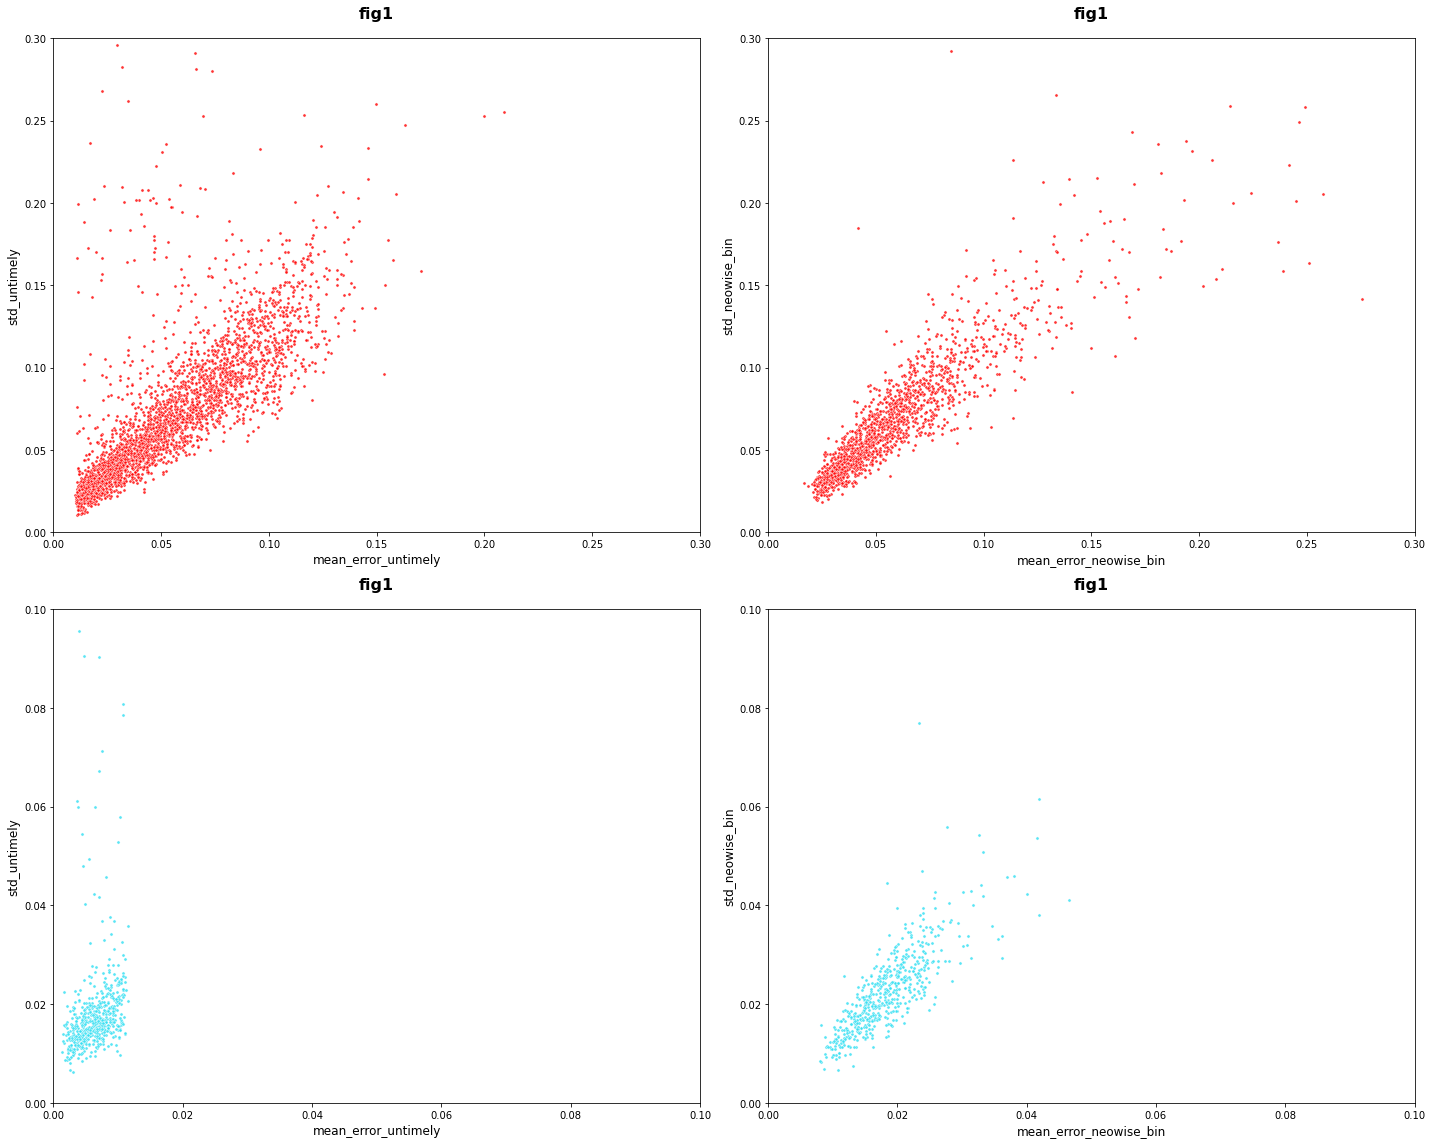

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

# 设置样式 - 使用您系统中可用的样式
plt.style.use('seaborn-pastel')  # 使用白色网格背景的seaborn样式

# 创建图形和坐标轴
plt.figure(figsize=(20, 16))

plt.subplot(2, 2, 1)

table_light = result_table[result_table['Mean']<=14]
table_dark = result_table[result_table['Mean']>14]

# 绘制散点图

scatter = plt.scatter(np.array(table_dark['mean_error_untimely']), np.array(table_dark['std_untimely']),
             c='r', s=10, cmap='viridis', alpha=0.8, edgecolors='w', linewidth=0.5)
plt.xlim(0, 0.3)
plt.ylim(0, 0.3)

# 添加标题和标签
plt.title('fig1', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('mean_error_untimely', fontsize=12)
plt.ylabel('std_untimely', fontsize=12)

plt.subplot(2, 2, 2)
scatter = plt.scatter(np.array(table_dark['mean_error_neowise_bin']),np.array(table_dark['std_neowise_bin']),
             c='r', s=10, cmap='viridis', alpha=0.8, edgecolors='w', linewidth=0.5)
plt.xlim(0, 0.3)
plt.ylim(0, 0.3)

# 添加标题和标签
plt.title('fig1', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('mean_error_neowise_bin', fontsize=12)
plt.ylabel('std_neowise_bin', fontsize=12)

plt.subplot(2, 2, 3)

scatter = plt.scatter(np.array(table_light['mean_error_untimely']), np.array(table_light['std_untimely']),
             c='#30DFF3', s=10, cmap='viridis', alpha=0.8, edgecolors='w', linewidth=0.5)

plt.xlim(0, 0.1)
plt.ylim(0, 0.1)

# 添加标题和标签
plt.title('fig1', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('mean_error_untimely', fontsize=12)
plt.ylabel('std_untimely', fontsize=12)

plt.subplot(2, 2, 4)

scatter = plt.scatter(np.array(table_light['mean_error_neowise_bin']),np.array(table_light['std_neowise_bin']),
             c='#30DFF3', s=10, cmap='viridis', alpha=0.8, edgecolors='w', linewidth=0.5)

plt.xlim(0, 0.1)
plt.ylim(0, 0.1)

# 添加标题和标签
plt.title('fig1', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('mean_error_neowise_bin', fontsize=12)
plt.ylabel('std_neowise_bin', fontsize=12)

# 美化坐标轴
# sns.despine(left=True, bottom=True)


# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

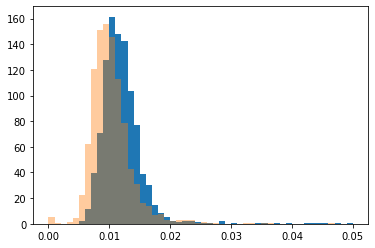

In [12]:
plt.hist(np.array(result_table['std_untimely']),bins=50,density=True,range=(0,0.05))
plt.hist(np.array(result_table['std_neowise_bin']),bins=50,density=True,range=(0,0.05),alpha=0.4)
plt.show()

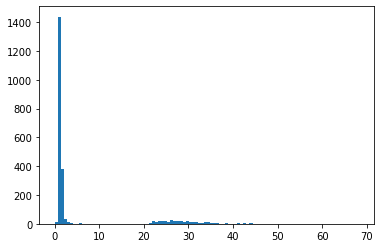

In [32]:
plt.hist(np.divide(np.array(result_table['std_neowise_bin']),
                   np.array(result_table['mean_error_neowise_bin'])),bins=100)
plt.show()

In [35]:
hist_list = np.histogram(np.divide(np.array(result_table['std_neowise_bin']),
                   np.array(result_table['mean_error_neowise_bin'])),bins=100,range=(0,20))
print(hist_list[0])
print(hist_list[1])
values = (np.array(hist_list[1][1:101])+np.array(hist_list[1][0:100]))/2
print(values)
mean_value = np.matmul(np.array(hist_list[0]),np.array(values))/np.sum(np.array(hist_list[0]))
print(mean_value)

[  5   1   2   5  28 646 865 197  50  31  17  10   4  11   5   4   2   1
   3   1   2   1   0   0   0   0   0   1   1   0   1   0   0   0   0   0
   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[ 0.   0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6
  2.8  3.   3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4
  5.6  5.8  6.   6.2  6.4  6.6  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2
  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10.  10.2 10.4 10.6 10.8 11.
 11.2 11.4 11.6 11.8 12.  12.2 12.4 12.6 12.8 13.  13.2 13.4 13.6 13.8
 14.  14.2 14.4 14.6 14.8 15.  15.2 15.4 15.6 15.8 16.  16.2 16.4 16.6
 16.8 17.  17.2 17.4 17.6 17.8 18.  18.2 18.4 18.6 18.8 19.  19.2 19.4
 19.6 19.8 20. ]
[ 0.1  0.3  0.5  0.7  0.9  1.1  1.3  1.5  1.7  1.9  2.1  2.3  2.5  2.7
  2.9  3.

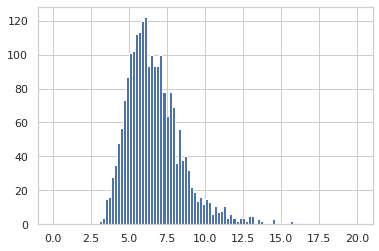

In [30]:
import matplotlib.pyplot as plt
plt.hist(np.divide(np.array(result_table['std_untimely']),
                   np.array(result_table['mean_error_untimely'])),
                   range=(0,20),bins=100)
plt.show()

In [7]:
import seaborn as sns

# 查看所有可用样式
print("Seaborn可用样式:", sns.style.available)

AttributeError: module 'seaborn' has no attribute 'style'

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


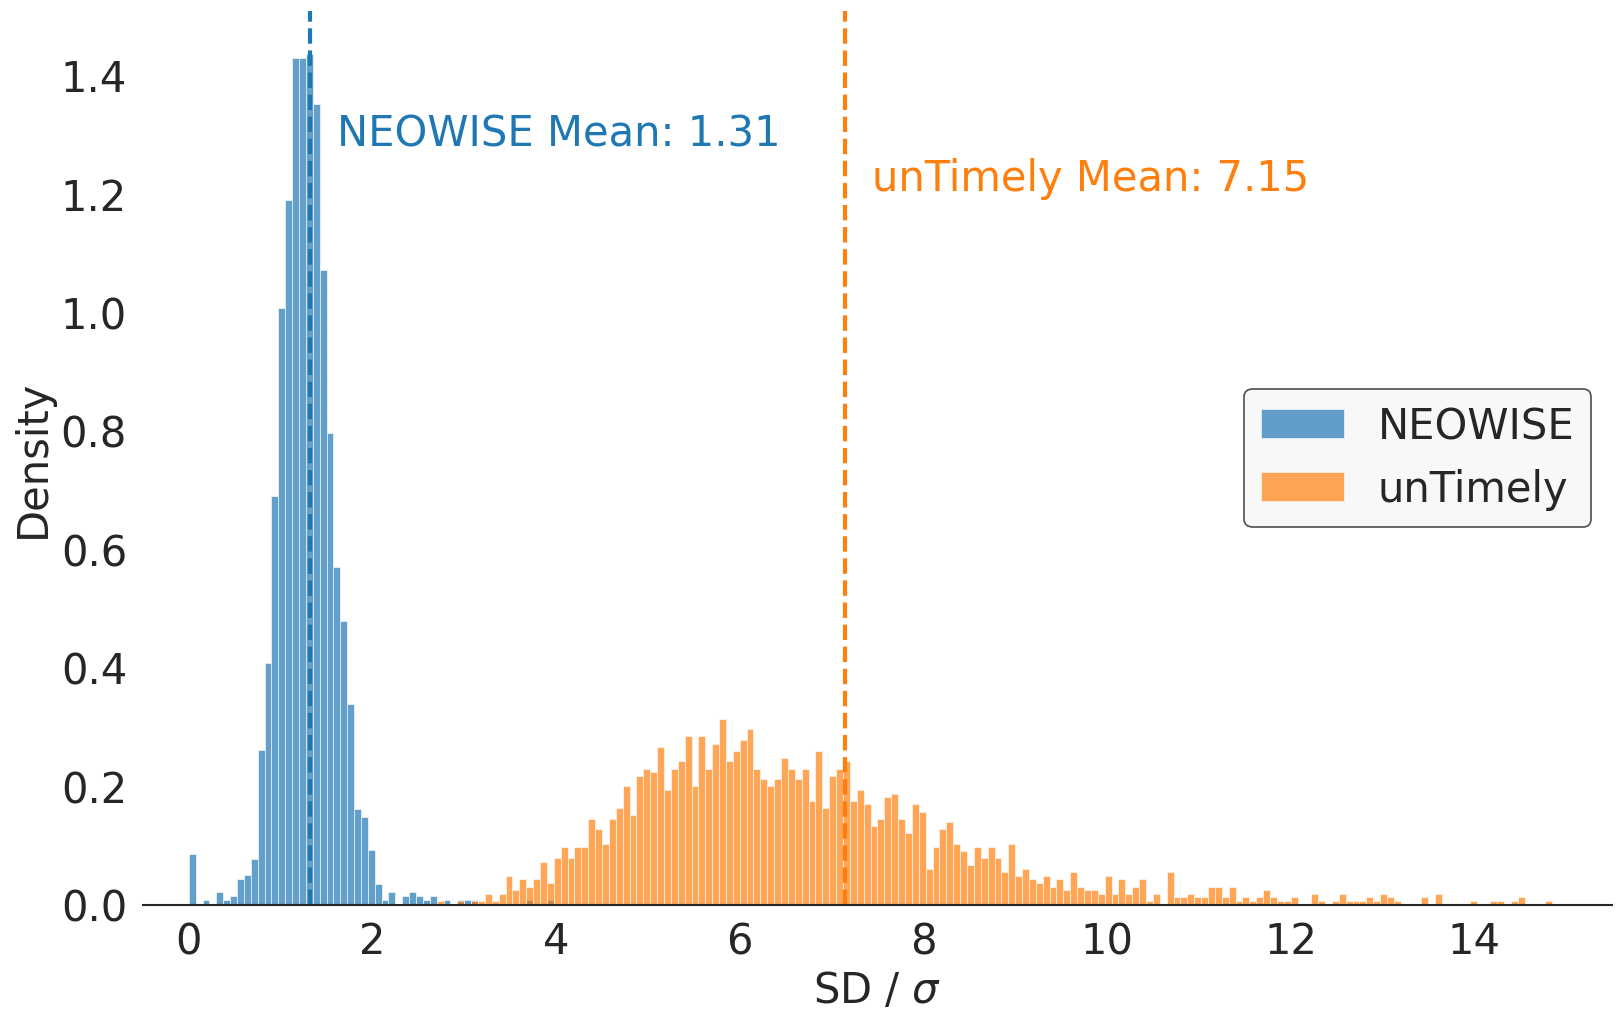

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# 创建数据
data2 = np.divide(np.array(result_table['std_untimely']), 
                 np.array(result_table['mean_error_untimely']))

data1 = np.divide(np.array(result_table['std_neowise_bin']), 
                 np.array(result_table['mean_error_neowise_bin']))

# 设置样式
sns.set_theme(style="white")  # 使用带网格线的现代样式
# sns.set_theme()  # 使用默认样式
plt.figure(figsize=(14, 9), dpi=120)  # 增加画布尺寸和分辨率

# 绘制第一个直方图
n1, bins1, patches1 = plt.hist(
    data1,
    bins=200,  # 减少bins数量避免拥挤
    range=(0, 15),
    color='#1f77b4',
    edgecolor='white',
    linewidth=0.5,  # 减小线宽
    alpha=0.7,       # 增加透明度
    density=True,
    label='NEOWISE'
)

# 绘制第二个直方图
n2, bins2, patches2 = plt.hist(
    data2,
    bins=200,  # 减少bins数量避免拥挤
    range=(0, 15),
    color='#ff7f0e',
    edgecolor='white',
    linewidth=0.5,  # 减小线宽
    alpha=0.7,       # 增加透明度
    density=True,
    label='unTimely'
)


# 字体和标签大小调整
plt.xlabel('SD / $\sigma$', fontsize=25)  # 增大轴标签
plt.ylabel('Density', fontsize=25)
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# 设置坐标轴范围
plt.xlim(-0.5, 15.5)  # 增加左右边距

# 添加均值线
mean1 = np.nanmean(data1)
mean2 = np.nanmean(data2)
plt.axvline(mean1, color='#1f77b4', linestyle='--', linewidth=2.5)
plt.axvline(mean2, color='#ff7f0e', linestyle='--', linewidth=2.5)

# 添加均值标注 - 增大字体
plt.text(mean1+0.3, plt.ylim()[1]*0.85, 
         f'NEOWISE Mean: {mean1:.2f}', 
         color='#1f77b4', fontsize=25)  # 增大到13
plt.text(mean2+0.3, plt.ylim()[1]*0.80, 
         f'unTimely Mean: {mean2:.2f}', 
         color='#ff7f0e', fontsize=25)

# 图例优化 - 增大字体和调整位置
legend = plt.legend(#title='Data Source', 
                   title_fontsize=25,  # 增大标题
                   fontsize=25,        # 增大标签
                   loc='right',
                   frameon=True,
                   framealpha=0.95,
                   edgecolor='#444444',
                   facecolor='#f8f8f8')
legend.get_title().set_fontsize(25)  # 确保标题大小

# 坐标轴刻度优化
plt.xticks(np.arange(0, 16, 2), fontsize=25)  # 增大刻度标签
plt.yticks(fontsize=25)
plt.gca().tick_params(axis='both', which='major', length=6, width=1)  # 增大刻度线

# 背景和布局优化
# plt.gca().set_facecolor('#f9f9f9')  # 更亮的背景
sns.despine(left=True)  # 移除左侧边框
# plt.grid(axis='y', alpha=0.4, linestyle=':')  # 更精细的网格

# 增加图表内边距
plt.subplots_adjust(left=0.1, right=0.95, top=0.92, bottom=0.1)

# 紧凑布局
plt.tight_layout(pad=2.0)  # 增加内边距
plt.savefig('error_level.eps', format='eps', dpi=10000)
# plt.show()

In [12]:
# 输出为eps矢量图
plt.savefig('error_level.eps', format='eps', dpi=1000)


<Figure size 432x288 with 0 Axes>

In [17]:
np.array(delta_w2)

/tmp/ipykernel_18846/760681103.py:1: UserWarning: Warning: converting a masked element to nan.
  np.array(delta_w2)


array([0.18 , 0.317, 0.297, ..., 0.259, 1.975, 0.337])

/tmp/ipykernel_18846/3244510315.py:2: UserWarning: Warning: converting a masked element to nan.
  plt.hist(np.divide(np.array(delta_w2),


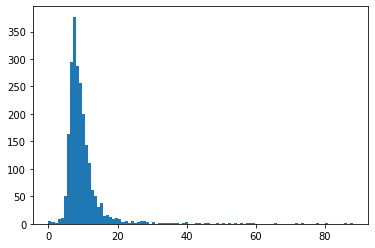

In [40]:
import matplotlib.pyplot as plt
plt.hist(np.divide(np.array(delta_w2),
                   np.array(result_table['mean_error_neowise_bin'])),
                   bins=100)
plt.show()

In [41]:
hist_list = np.histogram(np.divide(np.array(delta_w2),
                   np.array(result_table['mean_error_neowise_bin'])),bins=100,range=(0,200))
print(hist_list[0])
print(hist_list[1])
values = (np.array(hist_list[1][1:101])+np.array(hist_list[1][0:100]))/2
print(values)
mean_value = np.matmul(np.array(hist_list[0]),np.array(values))/np.sum(np.array(hist_list[0]))
print(mean_value)

[ 10  12 190 721 603 337 151  72  37  21  16   8   8  12   4   4   5   3
   4   3   2   2   2   1   1   2   1   2   1   2   0   0   1   0   0   1
   1   0   0   1   1   0   1   0   1   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200.]
[  1.   3.   5.   7.   9.  11.  13.  15.  17.  19.  21.  23.  25.  27.
  29.  3

/tmp/ipykernel_18846/2269327461.py:1: UserWarning: Warning: converting a masked element to nan.
  hist_list = np.histogram(np.divide(np.array(delta_w2),


/tmp/ipykernel_18846/2565283144.py:2: UserWarning: Warning: converting a masked element to nan.
  plt.hist(np.divide(np.array(delta_w2),


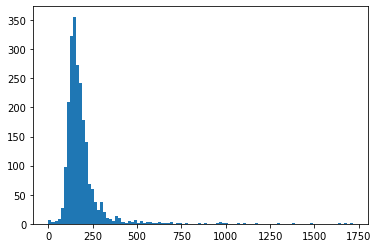

In [19]:
import matplotlib.pyplot as plt
plt.hist(np.divide(np.array(delta_w2),
                   np.array(result_table['mean_error_untimely'])),
                   bins=100)
plt.show()

In [26]:
hist_list = np.histogram(np.divide(np.array(delta_w2),
                   np.array(result_table['mean_error_untimely'])),bins=100,range=(0,2000))
print(hist_list[0])
print(hist_list[1])
values = (np.array(hist_list[1][1:101])+np.array(hist_list[1][0:100]))/2
print(values)
mean_value = np.matmul(np.array(hist_list[0]),np.array(values))/np.sum(np.array(hist_list[0]))
print(mean_value)

[  7   4   7  21  85 234 382 392 299 248 173  87  65  42  33  33  15  10
   8  16   5   4   4   3   7   2   4   2   4   3   1   3   2   3   3   0
   2   2   2   0   0   0   1   2   0   0   0   2   3   2   1   0   0   1
   0   1   0   0   1   0   0   0   0   0   1   0   0   0   0   1   0   0
   0   0   1   0   0   0   0   0   0   0   1   1   0   1   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[   0.   20.   40.   60.   80.  100.  120.  140.  160.  180.  200.  220.
  240.  260.  280.  300.  320.  340.  360.  380.  400.  420.  440.  460.
  480.  500.  520.  540.  560.  580.  600.  620.  640.  660.  680.  700.
  720.  740.  760.  780.  800.  820.  840.  860.  880.  900.  920.  940.
  960.  980. 1000. 1020. 1040. 1060. 1080. 1100. 1120. 1140. 1160. 1180.
 1200. 1220. 1240. 1260. 1280. 1300. 1320. 1340. 1360. 1380. 1400. 1420.
 1440. 1460. 1480. 1500. 1520. 1540. 1560. 1580. 1600. 1620. 1640. 1660.
 1680. 1700. 1720. 1740. 1760. 1780. 1800. 1820. 1840. 1860. 1880. 1900.
 1920. 19

/tmp/ipykernel_18846/3727533082.py:1: UserWarning: Warning: converting a masked element to nan.
  hist_list = np.histogram(np.divide(np.array(delta_w2),


In [32]:
hist_list = np.histogram(np.divide(np.array(result_table['std_untimely']),
                   np.array(result_table['mean_error_untimely'])),bins=100,range=(0,20))
print(hist_list[0])
print(hist_list[1])
values = (np.array(hist_list[1][1:101])+np.array(hist_list[1][0:100]))/2
print(values)
mean_value = np.matmul(np.array(hist_list[0]),np.array(values))/np.sum(np.array(hist_list[0]))
print(mean_value)

[  0   0   0   0   0   0   0   0   0   0   0   0   0   1   1   2   4  15
  16  28  35  48  57  73  87 101 102 112 113 120 122  93 100  93  93 100
  78  64  78  69  36  56  38  40  32  22  19  14  16  12  15  13   6  11
   7   8  11   4   6   4   2   4   4   2   5   5   0   3   2   1   1   1
   3   1   0   1   0   0   2   1   1   1   1   1   0   0   0   0   1   0
   0   0   0   0   0   0   0   0   0   0]
[ 0.   0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6
  2.8  3.   3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4
  5.6  5.8  6.   6.2  6.4  6.6  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2
  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10.  10.2 10.4 10.6 10.8 11.
 11.2 11.4 11.6 11.8 12.  12.2 12.4 12.6 12.8 13.  13.2 13.4 13.6 13.8
 14.  14.2 14.4 14.6 14.8 15.  15.2 15.4 15.6 15.8 16.  16.2 16.4 16.6
 16.8 17.  17.2 17.4 17.6 17.8 18.  18.2 18.4 18.6 18.8 19.  19.2 19.4
 19.6 19.8 20. ]
[ 0.1  0.3  0.5  0.7  0.9  1.1  1.3  1.5  1.7  1.9  2.1  2.3  2.5  2.7
  2.9  3.

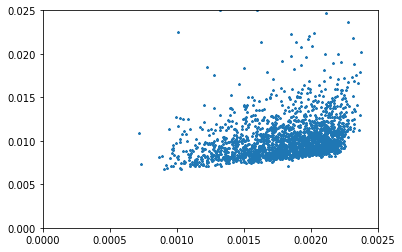

In [31]:
plt.scatter(np.array(result_table['mean_error_untimely']),
            np.array(result_table['mean_error_neowise_bin']),s=5,marker='*')
plt.axis([0,0.0025,0,0.025])
plt.show()